# 05 — Train Conv1D + GRU autoencoder & export to ONNX (KQL-deployable)

**Option A v2** — Conv1D + bidirectional GRU encoder with a tight Linear
bottleneck. Same data, same eval protocol, same `(B, W, F) → (B,)` ONNX
contract as `04_train_transformer_ae.ipynb` so the two `metadata.json`
files are directly comparable.

**Why bidirectional encoder + tight bottleneck**

v1 (single-direction GRU, hidden=64) under-fit clean data
(`val_loss ≈ 0.12`) and was particularly weak on `hydraulic_leak`
(slow drifts and oscillations). v2 adds:

- bidirectional encoder GRU — the bottleneck sees the whole window in
  both directions, capturing slow trends that the causal v1 missed.
- explicit `Linear` bottleneck (96 → 48) — a clean, ONNX-friendly
  compression step instead of relying on the last hidden state.
- slightly wider convs (24/48/96) + `LayerNorm` on the temporal axis
  for stable training.

**Deployment constraint (Kusto row)**

The KQL `python(...)` plugin loads the model from a base64 string in a
table row. Practical Kusto cell limit ≈ 1 MB, so raw ONNX must stay
≤ ~700 KB (base64 grows ~4/3). The sandbox onnxruntime also only
supports `ir_version ≤ 9`.

This notebook therefore writes **two** ONNX artifacts under
`models/conv_gru_ae/`:

- `model.onnx`     — FP32, IR=9, used locally and for parity checks
- `model.fp16.onnx` — FP16, IR=9, the one we upload as a row to the
  `models` table

It also prints raw + base64 sizes for both so we know they fit before
attempting the upload.


## 1. Config & imports

In [1]:
from __future__ import annotations

import base64
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 1337
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

REPO_ROOT  = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_TRAIN = REPO_ROOT / "data" / "training" / "telemetry_wide.parquet"
DATA_EVAL  = REPO_ROOT / "data" / "eval"     / "telemetry_wide.parquet"
DATA_LBL   = REPO_ROOT / "data" / "eval"     / "anomaly_labels.parquet"
ART_DIR    = REPO_ROOT / "models" / "conv_gru_ae"
ART_DIR.mkdir(parents=True, exist_ok=True)

SENSORS = [
    "vibration_axial", "vibration_radial",
    "temperature_motor", "temperature_bearing",
    "pressure_hydraulic", "current", "power", "spindle_rpm",
]
N_FEATURES = len(SENSORS)

# Windowing — identical to notebook 04.
WINDOW = 64
STRIDE_TRAIN = 16
STRIDE_EVAL  = 1

# Model (Option A v2)
CONV_CH1     = 24
CONV_CH2     = 48
CONV_CH3     = 96
GRU_HIDDEN   = 48      # per-direction; bidir doubles the encoder output
BOTTLENECK   = 48      # Linear compression after the bidir encoder
DEC_HIDDEN   = 96
DROPOUT      = 0.1

# Training
BATCH    = 256
EPOCHS   = 20
LR       = 5e-4
WEIGHT_DECAY = 1e-5
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Deployment target: must satisfy the Kusto sandbox.
SANDBOX_IR_VERSION = 9            # onnxruntime in the sandbox refuses higher
KUSTO_ROW_BUDGET_BYTES = 1_048_576  # 1 MB practical cap on a dynamic/string cell

print(f"device           : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"gpu              : {torch.cuda.get_device_name(0)}")
print(f"sensors          : {SENSORS}")
print(f"window / strides : W={WINDOW}, train_stride={STRIDE_TRAIN}, eval_stride={STRIDE_EVAL}")
print(f"artifact dir     : {ART_DIR.relative_to(REPO_ROOT)}")


device           : cuda
gpu              : NVIDIA GeForce RTX 2070 SUPER
sensors          : ['vibration_axial', 'vibration_radial', 'temperature_motor', 'temperature_bearing', 'pressure_hydraulic', 'current', 'power', 'spindle_rpm']
window / strides : W=64, train_stride=16, eval_stride=1
artifact dir     : models\conv_gru_ae


## 2. Load data

In [2]:
train_df = pd.read_parquet(DATA_TRAIN)
eval_df  = pd.read_parquet(DATA_EVAL)
labels_df = pd.read_parquet(DATA_LBL)

print(f"training rows : {len(train_df):>10,}  machines={sorted(train_df.machineId.unique())}")
print(f"eval rows     : {len(eval_df):>10,}  machines={sorted(eval_df.machineId.unique())}")
print(f"eval anomaly% : {100*eval_df['is_anomaly'].mean():.2f}%")
print(f"episodes      : {len(labels_df)}")
labels_df.head()


training rows :  4,320,000  machines=['M-001', 'M-002', 'M-003', 'M-004', 'M-005', 'M-006', 'M-007', 'M-008', 'M-009', 'M-010']
eval rows     :    691,200  machines=['M-101', 'M-102', 'M-103', 'M-104', 'M-105', 'M-106', 'M-107', 'M-108']
eval anomaly% : 26.43%
episodes      : 27


,machineId,fault_type,affected_sensor,onset_ts,end_ts,duration_s,severity_max,pattern,notes
0,M-103,bearing,NaN,2026-05-16 10:00:00+00:00,2026-05-16 11:30:00+00:00,5400.0,0.30,ramp,"early-stage, subdued"
1,M-103,bearing,NaN,2026-05-16 15:00:00+00:00,2026-05-16 17:00:00+00:00,7200.0,0.55,ramp,mid-stage
2,M-103,bearing,NaN,2026-05-16 21:00:00+00:00,2026-05-16 23:30:00+00:00,9000.0,0.80,ramp,advanced
3,M-103,bearing,NaN,2026-05-17 03:30:00+00:00,2026-05-17 06:30:00+00:00,10800.0,1.00,ramp,"late-stage, near failure"
4,M-104,hydraulic_leak,NaN,2026-05-16 11:00:00+00:00,2026-05-16 13:00:00+00:00,7200.0,0.40,ramp,"slow leak, mild"


In [3]:
def drop_off(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["state"] != "OFF"].copy()

train_on = drop_off(train_df).sort_values(["machineId", "ts"]).reset_index(drop=True)
eval_on  = drop_off(eval_df ).sort_values(["machineId", "ts"]).reset_index(drop=True)

print(f"training (ON) : {len(train_on):>10,} rows ({100*len(train_on)/len(train_df):.1f}% of full)")
print(f"eval     (ON) : {len(eval_on):>10,} rows ({100*len(eval_on)/len(eval_df):.1f}% of full)")


training (ON) :  4,214,008 rows (97.5% of full)
eval     (ON) :    672,870 rows (97.3% of full)


## 3. Normalize & window

In [4]:
mean = train_on[SENSORS].mean(axis=0).astype(np.float32)
std  = train_on[SENSORS].std(axis=0).replace(0, 1.0).astype(np.float32)
scaler = pd.DataFrame({"mean": mean, "std": std})
scaler


,mean,std
vibration_axial,0.187070,0.076935
vibration_radial,0.294480,0.106893
temperature_motor,38.258476,12.108175
temperature_bearing,35.681213,8.562527
pressure_hydraulic,112.655754,16.369593
current,7.530980,3.281373
power,3.342558,1.544981
spindle_rpm,2930.026123,35.911476


In [5]:
def normalize(df: pd.DataFrame) -> np.ndarray:
    return ((df[SENSORS].to_numpy(dtype=np.float32) - mean.values) / std.values).astype(np.float32)


def windows_for_machine(arr: np.ndarray, stride: int) -> np.ndarray:
    n = arr.shape[0]
    if n < WINDOW:
        return np.empty((0, WINDOW, N_FEATURES), dtype=np.float32)
    out = np.lib.stride_tricks.sliding_window_view(arr, window_shape=WINDOW, axis=0)[::stride]
    return np.ascontiguousarray(out.transpose(0, 2, 1))


def build_windows(df_on: pd.DataFrame, stride: int):
    chunks, prov = [], []
    for m_id, sub in df_on.groupby("machineId", sort=True):
        arr = normalize(sub)
        w = windows_for_machine(arr, stride)
        if len(w) == 0:
            continue
        chunks.append(w)
        sub_idx = sub.index.to_numpy()
        starts_pos = np.arange(len(w)) * stride
        for s in starts_pos:
            prov.append((m_id, int(sub_idx[s]), int(sub_idx[s + WINDOW - 1])))
    X = np.concatenate(chunks, axis=0) if chunks else np.empty((0, WINDOW, N_FEATURES), np.float32)
    prov_df = pd.DataFrame(prov, columns=["machineId", "row_start", "row_end"])
    return X, prov_df


t0 = time.time()
X_train, _ = build_windows(train_on, STRIDE_TRAIN)
print(f"train windows : {X_train.shape}  built in {time.time()-t0:.1f}s")
t0 = time.time()
X_eval,  prov_eval = build_windows(eval_on, STRIDE_EVAL)
print(f"eval  windows : {X_eval.shape}   built in {time.time()-t0:.1f}s")


train windows : (263342, 64, 8)  built in 1.0s


eval  windows : (672366, 64, 8)   built in 1.8s


## 4. Conv1D + bidirectional-GRU autoencoder (v2)

Encoder

1. `Conv1d(F → 24, k=7, pad=3)` + `LayerNorm` + `GELU`
2. `Conv1d(24 → 48, k=5, stride=2, pad=2)` + `LayerNorm` + `GELU` — seq 64 → 32
3. `Conv1d(48 → 96, k=5, stride=2, pad=2)` + `LayerNorm` + `GELU` — seq 32 → 16
4. Bidirectional `GRU(96 → 48)` → concat directions → 96-d per timestep
5. `mean` over timesteps → `Linear(96 → 48)` — the bottleneck `z`

Decoder

1. `Linear(48 → 96)` → broadcast to length-16 sequence
2. `GRU(96 → 96)`
3. `ConvTranspose1d(96 → 48, k=4, stride=2, pad=1)` — 16 → 32
4. `ConvTranspose1d(48 → 24, k=4, stride=2, pad=1)` — 32 → 64
5. `Conv1d(24 → F, k=7, pad=3)` — projection back to sensor space

The decoder only sees the single `BOTTLENECK`-dim latent vector, so the
AE constraint holds. The bidirectional encoder gives that latent a
global, non-causal view of the window — which is what `hydraulic_leak`
(slow drift) and `bearing` (gradual amplitude growth) need.

`LayerNorm` is applied per-channel after each conv block; the
`(B, C, L)` ↔ `(B, L, C)` transpose around it is intentional and exports
to ONNX cleanly.

In [6]:
class ChannelLayerNorm(nn.Module):
    """LayerNorm over the channel axis of (B, C, L). Exports cleanly to ONNX."""
    def __init__(self, num_channels: int):
        super().__init__()
        self.ln = nn.LayerNorm(num_channels)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.ln(x.transpose(1, 2)).transpose(1, 2)


class ConvGruAE(nn.Module):
    def __init__(self,
                 n_features: int = N_FEATURES, window: int = WINDOW,
                 c1: int = CONV_CH1, c2: int = CONV_CH2, c3: int = CONV_CH3,
                 enc_hidden: int = GRU_HIDDEN, bottleneck: int = BOTTLENECK,
                 dec_hidden: int = DEC_HIDDEN, dropout: float = DROPOUT):
        super().__init__()
        assert window % 4 == 0
        self.window = window
        self.bottleneck_len = window // 4
        self.bottleneck = bottleneck

        # Encoder convs (B, F, W) -> (B, c3, W/4)
        self.enc_conv = nn.Sequential(
            nn.Conv1d(n_features, c1, kernel_size=7, padding=3),
            ChannelLayerNorm(c1), nn.GELU(),
            nn.Conv1d(c1, c2, kernel_size=5, stride=2, padding=2),
            ChannelLayerNorm(c2), nn.GELU(),
            nn.Conv1d(c2, c3, kernel_size=5, stride=2, padding=2),
            ChannelLayerNorm(c3), nn.GELU(),
        )
        # Bidirectional encoder GRU
        self.enc_gru = nn.GRU(input_size=c3, hidden_size=enc_hidden,
                              batch_first=True, bidirectional=True)
        # Linear bottleneck (mean-pool + project)
        self.to_bottleneck = nn.Linear(enc_hidden * 2, bottleneck)
        self.enc_drop = nn.Dropout(dropout)

        # Decoder: expand bottleneck back to a length-W/4 sequence
        self.from_bottleneck = nn.Linear(bottleneck, dec_hidden)
        self.dec_gru = nn.GRU(input_size=dec_hidden, hidden_size=dec_hidden,
                              batch_first=True)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose1d(dec_hidden, c2, kernel_size=4, stride=2, padding=1),
            ChannelLayerNorm(c2), nn.GELU(),
            nn.ConvTranspose1d(c2, c1, kernel_size=4, stride=2, padding=1),
            ChannelLayerNorm(c1), nn.GELU(),
            nn.Conv1d(c1, n_features, kernel_size=7, padding=3),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, W, F)
        h = x.transpose(1, 2)                   # (B, F, W)
        h = self.enc_conv(h)                    # (B, c3, W/4)
        h = h.transpose(1, 2)                   # (B, W/4, c3)
        seq, _ = self.enc_gru(h)                # (B, W/4, 2*enc_hidden)
        pooled = seq.mean(dim=1)                # (B, 2*enc_hidden)
        z = self.enc_drop(self.to_bottleneck(pooled))  # (B, bottleneck)

        d0 = self.from_bottleneck(z)            # (B, dec_hidden)
        d_in = d0.unsqueeze(1).expand(-1, self.bottleneck_len, -1)
        d, _ = self.dec_gru(d_in)               # (B, W/4, dec_hidden)
        d = d.transpose(1, 2)                   # (B, dec_hidden, W/4)
        d = self.dec_conv(d)                    # (B, F, W)
        return d.transpose(1, 2)                # (B, W, F)


model = ConvGruAE().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")
print(model)


parameters: 162,536
ConvGruAE(
  (enc_conv): Sequential(
    (0): Conv1d(8, 24, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ChannelLayerNorm(
      (ln): LayerNorm((24,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (2): GELU(approximate='none')
    (3): Conv1d(24, 48, kernel_size=(5,), stride=(2,), padding=(2,))
    (4): ChannelLayerNorm(
      (ln): LayerNorm((48,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (5): GELU(approximate='none')
    (6): Conv1d(48, 96, kernel_size=(5,), stride=(2,), padding=(2,))
    (7): ChannelLayerNorm(
      (ln): LayerNorm((96,), eps=1e-05, elementwise_affine=True, bias=True)
    )
    (8): GELU(approximate='none')
  )
  (enc_gru): GRU(96, 48, batch_first=True, bidirectional=True)
  (to_bottleneck): Linear(in_features=96, out_features=48, bias=True)
  (enc_drop): Dropout(p=0.1, inplace=False)
  (from_bottleneck): Linear(in_features=48, out_features=96, bias=True)
  (dec_gru): GRU(96, 96, batch_first=True)
  (dec_conv)

## 5. Training loop

In [7]:
def split_train_val(X: np.ndarray, val_frac: float = 0.15, seed: int = SEED):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    cut = int(len(X) * (1 - val_frac))
    return idx[:cut], idx[cut:]


tr_idx, va_idx = split_train_val(X_train)

X_tr = torch.from_numpy(X_train[tr_idx])
X_va = torch.from_numpy(X_train[va_idx])

dl_tr = DataLoader(TensorDataset(X_tr), batch_size=BATCH, shuffle=True,
                   pin_memory=(DEVICE.type == "cuda"), drop_last=True)
dl_va = DataLoader(TensorDataset(X_va), batch_size=BATCH, shuffle=False,
                   pin_memory=(DEVICE.type == "cuda"))

print(f"train batches: {len(dl_tr):>6,}  ({len(X_tr):,} windows)")
print(f"val   batches: {len(dl_va):>6,}  ({len(X_va):,} windows)")


train batches:    874  (223,840 windows)
val   batches:    155  (39,502 windows)


In [8]:
def composite_loss(x_hat: torch.Tensor, x: torch.Tensor, lam_delta: float = 0.1) -> torch.Tensor:
    mse = torch.mean((x_hat - x) ** 2)
    dx_hat = x_hat[:, 1:, :] - x_hat[:, :-1, :]
    dx     = x[:, 1:, :]     - x[:, :-1, :]
    l1d    = torch.mean(torch.abs(dx_hat - dx))
    return mse + lam_delta * l1d


opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * max(1, len(dl_tr)))

history = []
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    tr_running = 0.0
    n_seen = 0
    for (xb,) in dl_tr:
        xb = xb.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        x_hat = model(xb)
        loss = composite_loss(x_hat, xb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        sched.step()
        tr_running += loss.item() * xb.size(0)
        n_seen += xb.size(0)
    tr_loss = tr_running / n_seen

    model.eval()
    va_running = 0.0
    n_seen_va = 0
    with torch.no_grad():
        for (xb,) in dl_va:
            xb = xb.to(DEVICE, non_blocking=True)
            x_hat = model(xb)
            va_running += composite_loss(x_hat, xb).item() * xb.size(0)
            n_seen_va += xb.size(0)
    va_loss = va_running / n_seen_va

    elapsed = time.time() - t0
    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss, "elapsed_s": elapsed})
    flag = ""
    if va_loss < best_val:
        best_val = va_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        flag = "  <- best"
    print(f"epoch {epoch:2d}/{EPOCHS}  train={tr_loss:.5f}  val={va_loss:.5f}  ({elapsed:.1f}s){flag}")

model.load_state_dict(best_state)
print(f"\nbest val loss: {best_val:.5f}")


epoch  1/20  train=0.15550  val=0.12702  (11.3s)  <- best


epoch  2/20  train=0.12752  val=0.12403  (11.2s)  <- best


epoch  3/20  train=0.12508  val=0.12313  (10.7s)  <- best


epoch  4/20  train=0.12337  val=0.12043  (10.7s)  <- best


epoch  5/20  train=0.12196  val=0.11920  (10.7s)  <- best


...

epoch 16/20  train=0.11219  val=0.10905  (10.7s)  <- best


epoch 17/20  train=0.11185  val=0.10861  (10.8s)  <- best


epoch 18/20  train=0.11167  val=0.10845  (10.7s)  <- best


epoch 19/20  train=0.11156  val=0.10837  (10.6s)  <- best


epoch 20/20  train=0.11152  val=0.10836  (10.8s)  <- best

best val loss: 0.10836


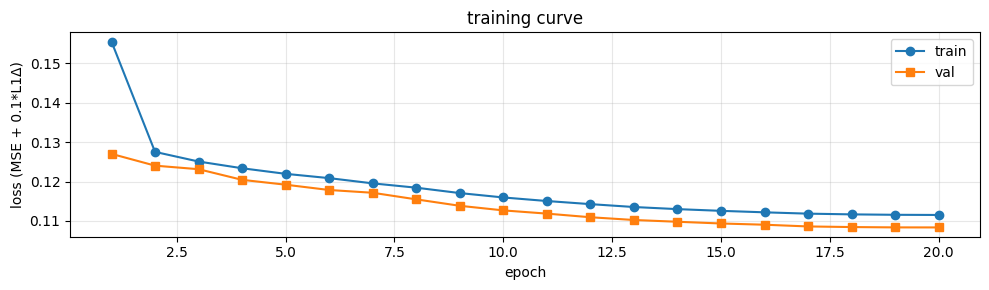

In [9]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(hist_df["epoch"], hist_df["train_loss"], label="train", marker="o")
ax.plot(hist_df["epoch"], hist_df["val_loss"],   label="val",   marker="s")
ax.set_xlabel("epoch"); ax.set_ylabel("loss (MSE + 0.1*L1Δ)")
ax.set_title("training curve")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


## 6. Score eval set

In [10]:
@torch.no_grad()
def score_windows(model: nn.Module, X: np.ndarray, batch: int = 1024) -> np.ndarray:
    model.eval()
    out = np.empty(len(X), dtype=np.float32)
    for i in range(0, len(X), batch):
        xb = torch.from_numpy(X[i:i+batch]).to(DEVICE, non_blocking=True)
        x_hat = model(xb)
        err = (x_hat - xb) ** 2
        per_sensor = err.mean(dim=1)
        s = per_sensor.max(dim=1).values
        out[i:i+batch] = s.detach().cpu().numpy()
    return out


t0 = time.time()
win_scores = score_windows(model, X_eval, batch=2048)
dt = time.time() - t0
print(f"scored {len(win_scores):,} windows in {dt:.1f}s "
      f"({len(win_scores)/max(dt,1e-6):,.0f} win/s)")


scored 672,366 windows in 4.0s (166,441 win/s)


In [11]:
def windows_to_rowscore(prov: pd.DataFrame, scores: np.ndarray,
                        eval_on: pd.DataFrame) -> np.ndarray:
    row_score = np.full(len(eval_on), -np.inf, dtype=np.float32)
    for m_id, sub in prov.groupby("machineId", sort=False):
        idx = sub.index.to_numpy()
        starts = sub["row_start"].to_numpy()
        ends   = sub["row_end"].to_numpy()
        s_arr  = scores[idx]
        for k in range(len(idx)):
            s, e = starts[k], ends[k] + 1
            cur = row_score[s:e]
            new = s_arr[k]
            np.maximum(cur, new, out=cur)
    return row_score


t0 = time.time()
row_score = windows_to_rowscore(prov_eval, win_scores, eval_on)
print(f"reduced to row scores in {time.time()-t0:.1f}s")
eval_on = eval_on.assign(score=row_score)
eval_on.head()


reduced to row scores in 1.2s


,ts,machineId,state,load,temperature_motor,temperature_bearing,vibration_axial,vibration_radial,current,spindle_rpm,pressure_hydraulic,power,fault_type,is_anomaly,score
0,2026-05-16 08:03:59+00:00,M-101,STARTUP,0.018127,21.543736,21.761002,0.106505,0.143078,1.123478,2989.877441,81.999092,0.252469,normal,False,0.136693
1,2026-05-16 08:04:00+00:00,M-101,STARTUP,0.032968,21.777565,22.471966,0.091531,0.142114,1.663533,2984.347656,81.523140,0.773606,normal,False,0.136693
2,2026-05-16 08:04:01+00:00,M-101,STARTUP,0.045119,22.232618,22.614231,0.131729,0.152751,1.371200,2969.694092,82.433807,0.519999,normal,False,0.136693
3,2026-05-16 08:04:02+00:00,M-101,STARTUP,0.055067,21.754972,21.398512,0.091396,0.165937,1.897591,3013.865723,84.131310,1.132069,normal,False,0.136693
4,2026-05-16 08:04:03+00:00,M-101,STARTUP,0.063212,22.398258,22.448954,0.112186,0.152257,2.410756,3008.250000,84.744919,1.024792,normal,False,0.136693


## 7. Metrics

In [12]:
val_scores = score_windows(model, X_train[va_idx], batch=2048)
THRESHOLD = float(np.quantile(val_scores, 0.995))
print(f"threshold (99.5 pct on training-val window scores): {THRESHOLD:.5f}")


threshold (99.5 pct on training-val window scores): 0.83698


In [13]:
from sklearn.metrics import precision_recall_curve, auc

def pr_auc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return float("nan")
    p, r, _ = precision_recall_curve(y_true, y_score)
    return float(auc(r, p))


y_true_all  = eval_on["is_anomaly"].to_numpy().astype(bool)
y_score_all = eval_on["score"].to_numpy()

valid = np.isfinite(y_score_all)
y_true  = y_true_all[valid]
y_score = y_score_all[valid]
eval_valid = eval_on.loc[valid].copy()

global_pr_auc = pr_auc(y_true, y_score)
print(f"global PR-AUC : {global_pr_auc:.4f}")
print()

fam_rows = []
for fam in ["bearing", "hydraulic_leak", "sensor_stuck"]:
    is_fam = (eval_valid["fault_type"] == fam).to_numpy()
    is_normal = (eval_valid["fault_type"] == "normal").to_numpy()
    keep = is_fam | is_normal
    auc_fam = pr_auc(is_fam[keep].astype(bool), y_score[keep])
    fam_rows.append({"family": fam, "pr_auc": auc_fam,
                     "positive_rows": int(is_fam.sum()),
                     "negative_rows": int(is_normal.sum())})
fam_df = pd.DataFrame(fam_rows)
fam_df


global PR-AUC : 0.4664



,family,pr_auc,positive_rows,negative_rows
0,bearing,0.242979,64005,493364
1,hydraulic_leak,0.229088,58059,493364
2,sensor_stuck,0.442062,57442,493364


In [14]:
flagged = eval_valid.assign(flag=(y_score > THRESHOLD))

def episode_delay(row):
    m_id = row["machineId"]
    t0 = row["onset_ts"]
    t1 = row["end_ts"]
    sub = flagged[(flagged["machineId"] == m_id)
                  & (flagged["ts"] >= t0)
                  & (flagged["ts"] <  t1)
                  & (flagged["flag"])]
    if len(sub) == 0:
        return float("nan")
    return (sub["ts"].iloc[0] - t0).total_seconds()


labels_df["detection_delay_s"] = labels_df.apply(episode_delay, axis=1)
print("Detection delay by fault family (seconds; NaN = missed episode):")
delay_summary = labels_df.groupby("fault_type")["detection_delay_s"].agg(
    n="count",
    detected=lambda s: int(s.notna().sum()),
    median_delay_s="median",
    p90_delay_s=lambda s: float(np.nanpercentile(s, 90)) if s.notna().any() else float("nan"),
)
print(delay_summary.to_string())
labels_df[["machineId", "fault_type", "severity_max", "pattern", "duration_s", "detection_delay_s"]]


Detection delay by fault family (seconds; NaN = missed episode):
                n  detected  median_delay_s  p90_delay_s
fault_type                                              
bearing         8         8          1139.0       5567.1
hydraulic_leak  9         9          1663.0       4363.8
sensor_stuck    7         7          1861.0       4371.6


,machineId,fault_type,severity_max,pattern,duration_s,detection_delay_s
0,M-103,bearing,0.30,ramp,5400.0,806.0
1,M-103,bearing,0.55,ramp,7200.0,6755.0
2,M-103,bearing,0.80,ramp,9000.0,5058.0
3,M-103,bearing,1.00,ramp,10800.0,8.0
4,M-104,hydraulic_leak,0.40,ramp,7200.0,4223.0
5,M-104,hydraulic_leak,0.70,oscillation,3600.0,1053.0
6,M-104,hydraulic_leak,0.85,ramp,9000.0,140.0
7,M-104,hydraulic_leak,1.00,oscillation,7200.0,3235.0
8,M-105,sensor_stuck,1.00,ramp,1800.0,NaN
9,M-105,sensor_stuck,1.00,ramp,5400.0,2860.0


In [15]:
healthy = eval_valid[eval_valid["machineId"].isin(["M-101", "M-102"])]
healthy_flag = (healthy["score"].to_numpy() > THRESHOLD)
fpr = float(healthy_flag.mean())
print(f"healthy-machine FP rate (M-101 union M-102, ON rows): {100*fpr:.3f}%  "
      f"({int(healthy_flag.sum()):,} / {len(healthy):,})")


healthy-machine FP rate (M-101 union M-102, ON rows): 3.675%  (6,161 / 167,628)


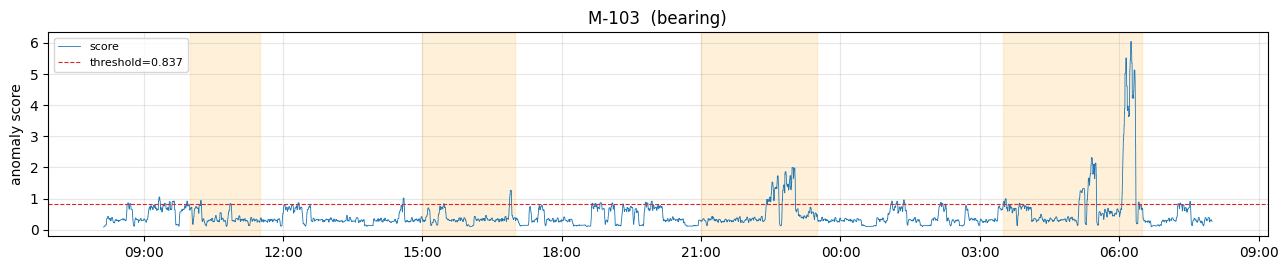

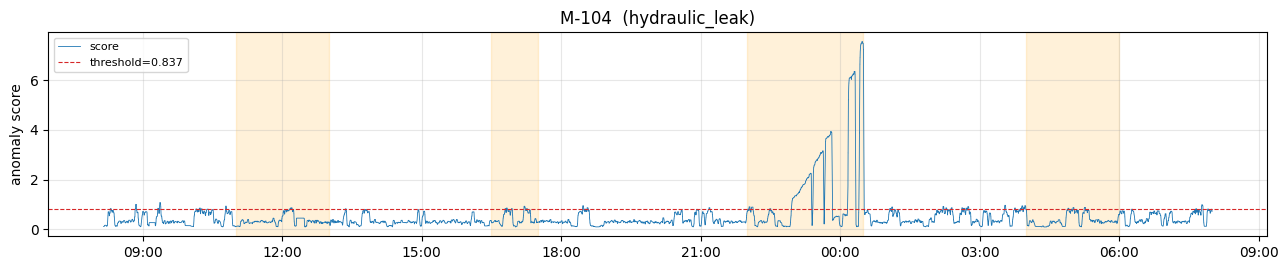

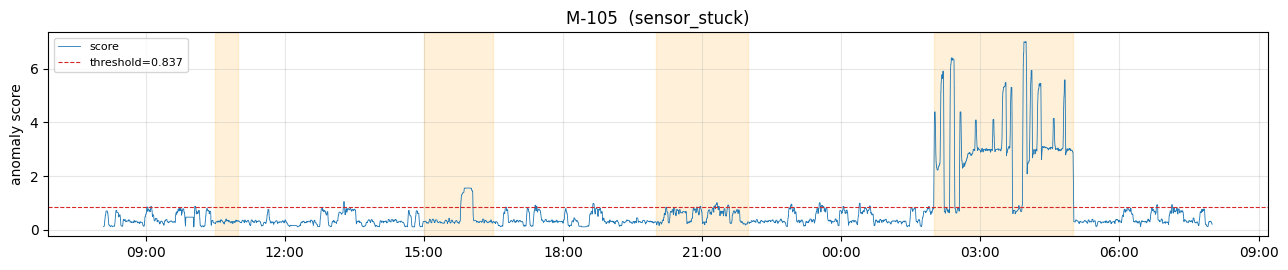

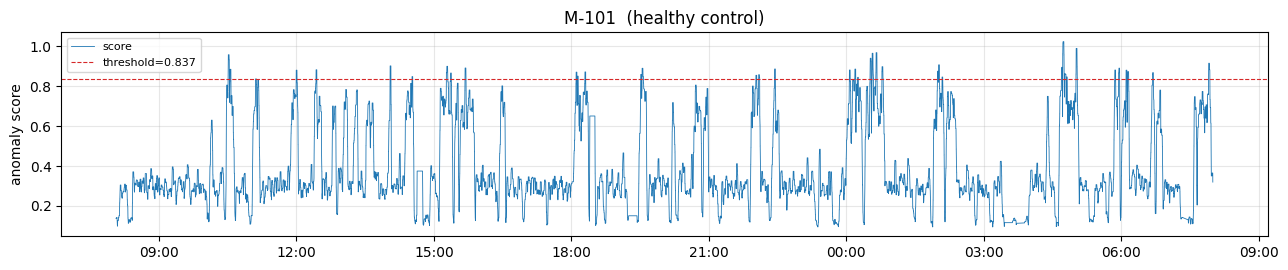

In [16]:
import matplotlib.dates as mdates

def plot_machine(m_id: str, fault: str):
    sub = eval_valid[eval_valid["machineId"] == m_id]
    fig, ax = plt.subplots(figsize=(13, 2.8))
    ax.plot(sub["ts"], sub["score"], lw=0.6, color="tab:blue", label="score")
    ax.axhline(THRESHOLD, color="tab:red", ls="--", lw=0.8, label=f"threshold={THRESHOLD:.3f}")
    eps = labels_df[labels_df["machineId"] == m_id]
    for _, e in eps.iterrows():
        ax.axvspan(e["onset_ts"], e["end_ts"], color="orange", alpha=0.15)
    ax.set_title(f"{m_id}  ({fault})"); ax.set_ylabel("anomaly score")
    ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.tight_layout(); plt.show()


plot_machine("M-103", "bearing")
plot_machine("M-104", "hydraulic_leak")
plot_machine("M-105", "sensor_stuck")
plot_machine("M-101", "healthy control")


## 8. ONNX export — FP32 (local) + FP16 (KQL row)

We export the `ScoreWrapper` so the ONNX graph already returns the
per-window scalar score (same contract as notebook 04). Then:

1. Clamp `ir_version` to 9 — the Kusto Python sandbox refuses higher.
2. Convert the FP32 graph to FP16 with `onnxconverter_common`, keeping
   the I/O tensors in FP32 so callers can keep sending `float32`
   windows.
3. Report raw + base64 sizes against the 1 MB Kusto cell budget.

In [17]:
import onnx
import onnxruntime as ort
from onnxconverter_common import float16


class ScoreWrapper(nn.Module):
    def __init__(self, ae: nn.Module):
        super().__init__()
        self.ae = ae
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_hat = self.ae(x)
        err = (x_hat - x) ** 2
        per_sensor = err.mean(dim=1)
        return per_sensor.max(dim=1).values


export_model = ScoreWrapper(model).to("cpu").eval()

ONNX_PATH      = ART_DIR / "model.onnx"
ONNX_FP16_PATH = ART_DIR / "model.fp16.onnx"

dummy = torch.randn(1, WINDOW, N_FEATURES, dtype=torch.float32)

# 1) FP32 export with the legacy tracer (dynamo path is brittle for GRU + expand).
torch.onnx.export(
    export_model, dummy, ONNX_PATH.as_posix(),
    input_names=["window"], output_names=["score"],
    dynamic_axes={"window": {0: "batch"}, "score": {0: "batch"}},
    opset_version=17, do_constant_folding=True, dynamo=False,
)

# 2) Force IR version <= 9 for the sandbox runtime.
mp_fp32 = onnx.load(ONNX_PATH.as_posix())
if mp_fp32.ir_version > SANDBOX_IR_VERSION:
    mp_fp32.ir_version = SANDBOX_IR_VERSION
onnx.save(mp_fp32, ONNX_PATH.as_posix())
onnx.checker.check_model(mp_fp32)
print(f"FP32  ir={mp_fp32.ir_version}  opset={mp_fp32.opset_import[0].version}")

# 3) Convert to FP16 (weights only; I/O stays float32 so callers don't change).
mp_fp16 = float16.convert_float_to_float16(
    mp_fp32, keep_io_types=True, disable_shape_infer=True,
)
if mp_fp16.ir_version > SANDBOX_IR_VERSION:
    mp_fp16.ir_version = SANDBOX_IR_VERSION
onnx.save(mp_fp16, ONNX_FP16_PATH.as_posix())
onnx.checker.check_model(mp_fp16)
print(f"FP16  ir={mp_fp16.ir_version}  opset={mp_fp16.opset_import[0].version}")


C:\Users\faust\AppData\Local\Temp\ipykernel_2284\2703714474.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
E:\coding\anomaly-detection-fabric-demo\.venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset9.py:4570: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with GRU can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  return _generic_rnn(


FP32  ir=8  opset=17
FP16  ir=8  opset=17


In [18]:
def size_report(path: Path, budget: int = KUSTO_ROW_BUDGET_BYTES) -> dict:
    raw = path.read_bytes()
    b64 = base64.b64encode(raw)
    info = {
        "path":         str(path.relative_to(REPO_ROOT)),
        "raw_bytes":    len(raw),
        "raw_kb":       round(len(raw) / 1024, 1),
        "base64_bytes": len(b64),
        "base64_kb":    round(len(b64) / 1024, 1),
        "kusto_row_fits": len(b64) <= budget,
        "budget_kb":    round(budget / 1024, 1),
    }
    return info

fp32_info = size_report(ONNX_PATH)
fp16_info = size_report(ONNX_FP16_PATH)
print(f"Kusto row budget : {fp32_info['budget_kb']} KB (base64-encoded payload)")
print()
print(f"FP32  raw={fp32_info['raw_kb']} KB   base64={fp32_info['base64_kb']} KB   "
      f"fits={fp32_info['kusto_row_fits']}")
print(f"FP16  raw={fp16_info['raw_kb']} KB   base64={fp16_info['base64_kb']} KB   "
      f"fits={fp16_info['kusto_row_fits']}")


Kusto row budget : 1024.0 KB (base64-encoded payload)

FP32  raw=651.3 KB   base64=868.4 KB   fits=True
FP16  raw=334.2 KB   base64=445.7 KB   fits=True


In [19]:
# Parity checks: both ONNX variants vs the PyTorch reference.
sample = X_eval[:128].astype(np.float32)

with torch.no_grad():
    torch_scores = export_model(torch.from_numpy(sample)).numpy()

sess_fp32 = ort.InferenceSession(ONNX_PATH.as_posix(), providers=["CPUExecutionProvider"])
ort_fp32  = sess_fp32.run(["score"], {"window": sample})[0]
diff_fp32 = float(np.max(np.abs(ort_fp32 - torch_scores)))
print(f"FP32 ONNX vs PyTorch max |diff| (128 windows): {diff_fp32:.2e}")
assert diff_fp32 < 1e-3, "FP32 ONNX drifted from PyTorch"

sess_fp16 = ort.InferenceSession(ONNX_FP16_PATH.as_posix(), providers=["CPUExecutionProvider"])
ort_fp16  = sess_fp16.run(["score"], {"window": sample})[0]
diff_fp16 = float(np.max(np.abs(ort_fp16 - torch_scores)))
rel_fp16  = float(np.max(np.abs(ort_fp16 - torch_scores) / np.maximum(np.abs(torch_scores), 1e-6)))
print(f"FP16 ONNX vs PyTorch max |abs diff|            : {diff_fp16:.2e}")
print(f"FP16 ONNX vs PyTorch max |rel diff|            : {rel_fp16:.2%}")
# FP16 weights lose ~3 decimal digits of precision; 2% relative is fine for thresholding.
assert rel_fp16 < 0.05, "FP16 ONNX drifted unexpectedly far from FP32"
print("parity OK (both variants)")


FP32 ONNX vs PyTorch max |diff| (128 windows): 7.45e-08


FP16 ONNX vs PyTorch max |abs diff|            : 1.34e-04
FP16 ONNX vs PyTorch max |rel diff|            : 0.12%
parity OK (both variants)


In [20]:
SCALER_PATH = ART_DIR / "scaler.json"
META_PATH   = ART_DIR / "metadata.json"

scaler_payload = {
    "sensors": SENSORS,
    "mean":    [float(x) for x in mean.values],
    "std":     [float(x) for x in std.values],
}
SCALER_PATH.write_text(json.dumps(scaler_payload, indent=2))

meta_payload = {
    "model":            "conv_gru_ae",
    "architecture_version": 2,
    "window":           WINDOW,
    "stride_train":     STRIDE_TRAIN,
    "stride_eval":      STRIDE_EVAL,
    "n_features":       N_FEATURES,
    "conv_channels":    [CONV_CH1, CONV_CH2, CONV_CH3],
    "gru_hidden":       GRU_HIDDEN,
    "encoder_bidirectional": True,
    "bottleneck_dim":   BOTTLENECK,
    "decoder_hidden":   DEC_HIDDEN,
    "n_parameters":     n_params,
    "threshold":        THRESHOLD,
    "threshold_rule":   "p99.5 on training-val window scores",
    "training": {
        "epochs":       EPOCHS,
        "batch":        BATCH,
        "lr":           LR,
        "weight_decay": WEIGHT_DECAY,
        "best_val_loss": best_val,
        "device":       str(DEVICE),
    },
    "metrics": {
        "global_pr_auc": global_pr_auc,
        "per_family":    fam_df.set_index("family")["pr_auc"].to_dict(),
        "healthy_fp_rate": fpr,
        "detection_delay_summary":
            delay_summary.reset_index().to_dict(orient="records"),
    },
    "onnx": {
        "ir_version":   SANDBOX_IR_VERSION,
        "fp32":         fp32_info,
        "fp16":         fp16_info,
        "parity_fp32_max_abs_diff": diff_fp32,
        "parity_fp16_max_abs_diff": diff_fp16,
        "parity_fp16_max_rel_diff": rel_fp16,
    },
    "kusto_deployable": fp16_info["kusto_row_fits"],
}
META_PATH.write_text(json.dumps(meta_payload, indent=2, default=str))

torch.save(model.state_dict(), ART_DIR / "model.pt")

print("Artifacts written:")
for p in sorted(ART_DIR.iterdir()):
    print(f"  {p.relative_to(REPO_ROOT)}   {p.stat().st_size/1024:>8.1f} KB")


Artifacts written:
  models\conv_gru_ae\metadata.json        2.1 KB
  models\conv_gru_ae\model.fp16.onnx      334.2 KB
  models\conv_gru_ae\model.onnx      651.3 KB
  models\conv_gru_ae\model.pt      645.1 KB
  models\conv_gru_ae\scaler.json        0.6 KB


## 9. Summary

| | |
|---|---|
| Model | Conv1D + bidirectional GRU autoencoder (v2) |
| Bottleneck | `Linear(2*GRU_HIDDEN → BOTTLENECK)` after mean-pool |
| Deployment | `model.fp16.onnx` is the row to upload to the `models` table |
| Sandbox IR | clamped to 9 (sandbox `onnxruntime` requirement) |
| Threshold rule | 99.5° percentile on training-val window scores |

Next steps:

- If `model.fp16.onnx` base64 size is still close to 1 MB, drop
  `CONV_CH3` to 64 or `DEC_HIDDEN` to 64 — both shrink the parameter
  count without major accuracy impact.
- If accuracy on `sensor_stuck` regresses vs v1 (single-direction
  encoder may be biased toward smooth signals), add a small per-sensor
  variance feature to the input.
